# Site da disciplina

https://sites.google.com/view/disciplinasebelati

# Bibliografia

Computational Intelligence Book:
- https://www.computational-intelligence.eu/

# Eggholder function

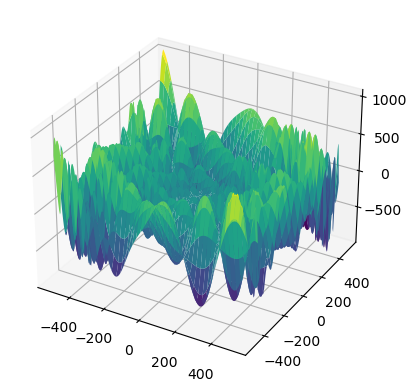

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def eggholder(x, y):
    return -(y + 47) * np.sin(np.sqrt(np.abs(x/2 + (y + 47)))) - x * np.sin(np.sqrt(np.abs(x - (y + 47))))

X = np.linspace(-512, 512, 256)
Y = np.linspace(-512, 512, 256)
X, Y = np.meshgrid(X, Y)
Z = eggholder(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


# Shubert function

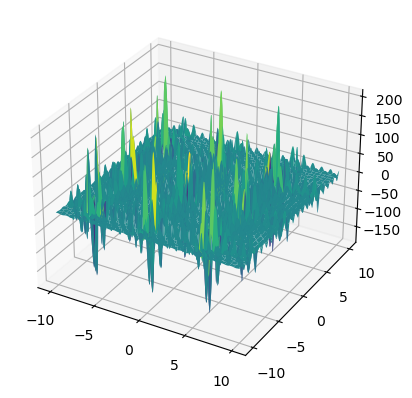

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def shubert(x, y):
    total = 0
    for i in range(1, 6):
        for j in range(1, 6):
            total += i * np.cos((i + 1) * x + i) * j * np.cos((j + 1) * y + j)
    return total

X = np.linspace(-10, 10, 256)
Y = np.linspace(-10, 10, 256)
X, Y = np.meshgrid(X, Y)
Z = shubert(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


# Griewank function

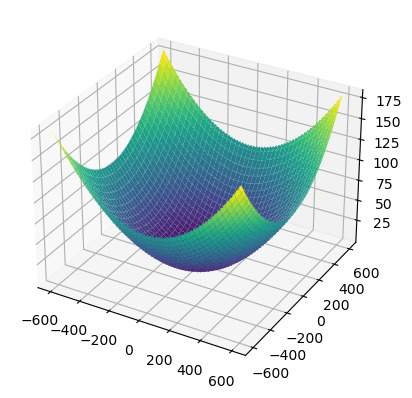

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def griewank(x, y):
    return (x**2 / 4000) + (y**2 / 4000) - np.cos(x) * np.cos(y/np.sqrt(2)) + 1

X = np.linspace(-600, 600, 256)
Y = np.linspace(-600, 600, 256)
X, Y = np.meshgrid(X, Y)
Z = griewank(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
plt.show()


# Dichotomous search for single variable

In [119]:
def dichotomous_search(f, a, b, epsilon):
    print(f"it \ta \tb \tintervalo  \tx1 \tx2 \tf_x1   \tf_x2")
    it = 0
    while abs(a - b) >= epsilon*10.0:
        x1 = (a + b)/2.0 - epsilon
        x2 = (a + b)/2.0 + epsilon
        f_x1 = f(x1)
        f_x2 = f(x2)
        if f_x1 > f_x2:
            a = x1
        else:
            b = x2

        it += 1
        erro = abs(a-b)
        
        print(f"{it} \t{a:.4f} \t{b:.4f} \t{erro:.4f}  \t{x1:.4f} \t{x2:.4f} \t{f_x1:.4f} \t{f_x2:.4f}")
    return (a + b) / 2.0

# Dichotomous search for multi variable


In [120]:
import numpy as np

def dichotomous_search_multi(f, bounds, epsilon):
    n = len(bounds)
    x = np.zeros(n)
    for i in range(n):
        a, b = bounds[i]
        while (b - a) >= epsilon:
            x1 = (a + b - epsilon) / 2
            x2 = (a + b + epsilon) / 2
            x[i] = x1
            f_x1 = f(x)
            x[i] = x2
            f_x2 = f(x)
            if f_x1 < f_x2:
                b = x2
            else:
                a = x1
        x[i] = (a + b) / 2
    return x

In [121]:
def f(x):
    return 8*x**3 - 2*x**2 - 7*x + 3

In [122]:
x1 = dichotomous_search(f, 0.0, 2.0, 0.00001)
x1

it 	a 	b 	intervalo  	x1 	x2 	f_x1   	f_x2
1 	0.0000 	1.0000 	1.0000  	1.0000 	1.0000 	1.9999 	2.0001
2 	0.5000 	1.0000 	0.5000  	0.5000 	0.5000 	0.0000 	-0.0000
3 	0.5000 	0.7500 	0.2500  	0.7500 	0.7500 	-0.0000 	0.0000
4 	0.6250 	0.7500 	0.1250  	0.6250 	0.6250 	-0.2031 	-0.2031
5 	0.6250 	0.6875 	0.0625  	0.6875 	0.6875 	-0.1582 	-0.1582
6 	0.6250 	0.6563 	0.0313  	0.6562 	0.6563 	-0.1941 	-0.1941
7 	0.6250 	0.6406 	0.0156  	0.6406 	0.6406 	-0.2019 	-0.2019
8 	0.6250 	0.6328 	0.0078  	0.6328 	0.6328 	-0.2033 	-0.2033
9 	0.6289 	0.6328 	0.0039  	0.6289 	0.6289 	-0.2034 	-0.2034
10 	0.6289 	0.6309 	0.0020  	0.6309 	0.6309 	-0.2034 	-0.2034
11 	0.6289 	0.6299 	0.0010  	0.6299 	0.6299 	-0.2034 	-0.2034
12 	0.6294 	0.6299 	0.0005  	0.6294 	0.6294 	-0.2034 	-0.2034
13 	0.6296 	0.6299 	0.0003  	0.6296 	0.6297 	-0.2034 	-0.2034
14 	0.6298 	0.6299 	0.0001  	0.6298 	0.6298 	-0.2034 	-0.2034
15 	0.6298 	0.6298 	0.0001  	0.6298 	0.6298 	-0.2034 	-0.2034


0.6297949618530273

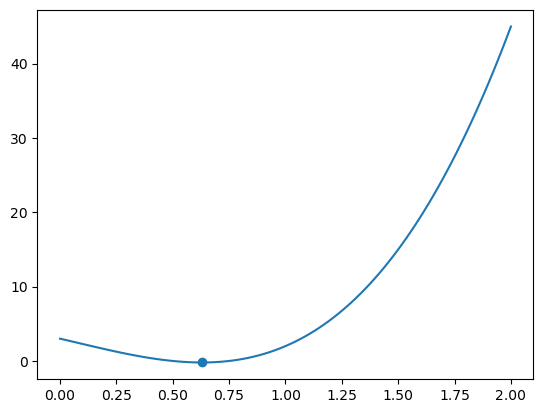

In [123]:
x = np.linspace(0,2,100)
plt.plot(x, f(x))
plt.scatter(x1, f(x1))

In [124]:
import numpy as np
from autograd import grad

def newton_method(f, x0, epsilon, max_iterations=100):
    df = grad(f)
    d2f = grad(df)
    x = x0
    iteration = 0
    while True:
        f_x = f(x)
        df_x = df(float(x))
        d2f_x = d2f(float(x))
        x_new = x - df_x / d2f_x
        print(f"Iteration {iteration}: x = {x_new}, f(x) = {f_x}")
        if np.abs(x_new - x) < epsilon or iteration >= max_iterations:
            break
        x = x_new
        iteration += 1
    return x_new


In [125]:
def f(x):
    return 8*x**3 - 2*x**2 - 7*x + 3

def df(x):
    return 24*x**4 - 4*x - 7

In [126]:
newton_method(f, 1.9, 0.00001)

Iteration 0: x = 1.073853211009174, f(x) = 37.352
Iteration 1: x = 0.7293278095799189, f(x) = 3.0833088108451596
Iteration 2: x = 0.6374556987534785, f(x) = -0.06558590750305182
Iteration 3: x = 0.6298396149474169, f(x) = -0.2026496252770884
Iteration 4: x = 0.6297865462687098, f(x) = -0.2034245606987497
Iteration 5: x = 0.6297865436918334, f(x) = -0.20342459763875942


0.6297865436918334